In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('../data/cleaned/clean_sales.csv')
print(f"Shape: {df.shape}")
print("Clean data loaded successfully!")

Shape: (9800, 19)
Clean data loaded successfully!


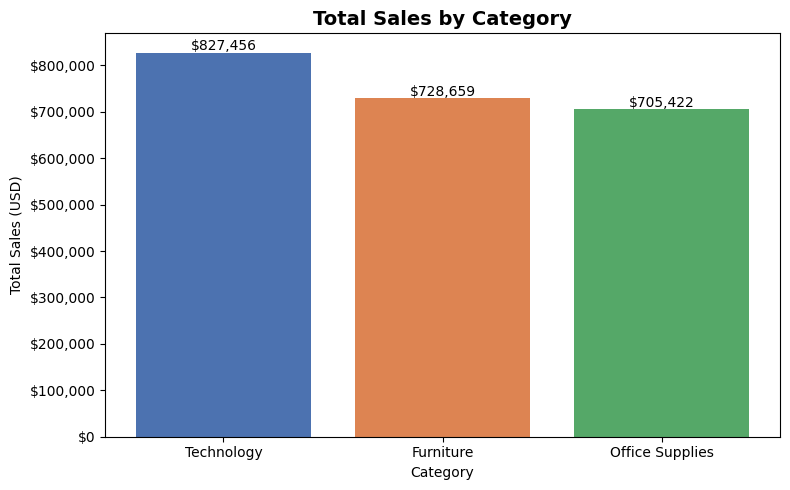

Chart saved!


In [2]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_sales.index, category_sales.values, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../visualizations/01_sales_by_category.png', dpi=150)
plt.show()
print("Chart saved!")

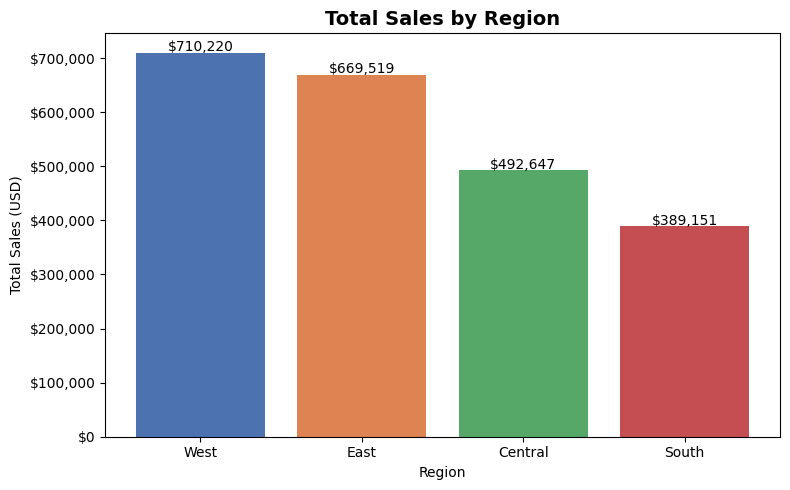

Chart saved!


In [3]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(region_sales.index, region_sales.values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../visualizations/02_sales_by_region.png', dpi=150)
plt.show()
print("Chart saved!")

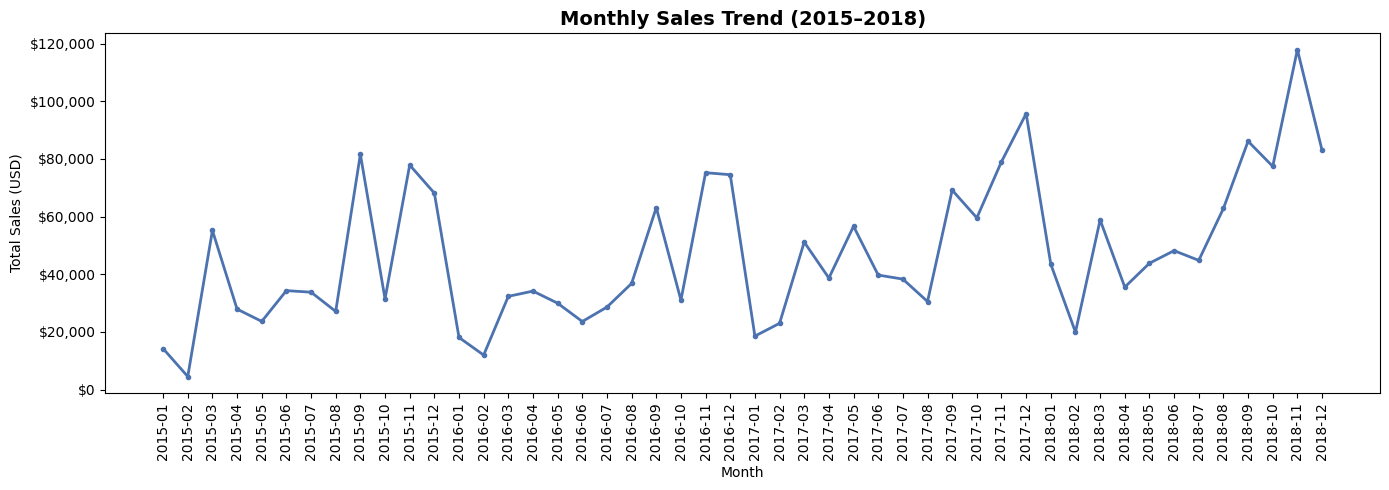

Chart saved!


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values, color='#4C72B0', linewidth=2, marker='o', markersize=3)
plt.title('Monthly Sales Trend (2015–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=90)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../visualizations/03_monthly_sales_trend.png', dpi=150)
plt.show()
print("Chart saved!")

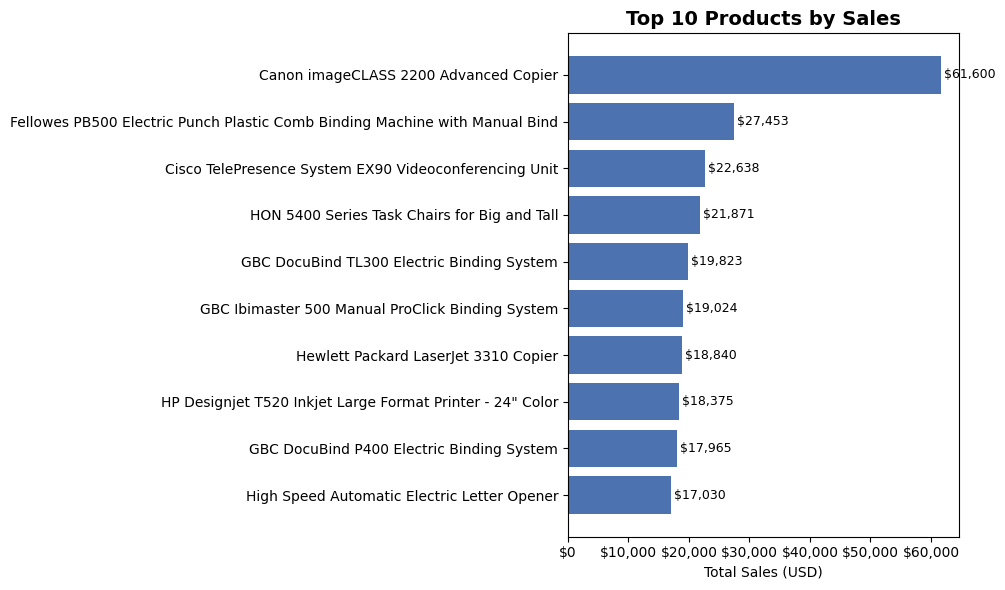

Chart saved!


In [5]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_products.index[::-1], top_products.values[::-1], color='#4C72B0')
plt.title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales (USD)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../visualizations/04_top10_products.png', dpi=150)
plt.show()
print("Chart saved!")